# Trim vs Hold Backtest
Tail-risk-focused workflow for evaluating trim/take-profit parameters across real and synthetic regimes.

In [6]:
import os
import sys
import importlib

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import functions2 as f2
import functions1 as f1
from config import params

importlib.reload(f2)
importlib.reload(f1)

<module 'functions1' from '/Users/alexwebb/laptop_coding/risk_matrix/functions1.py'>

In [7]:
# Run configuration
datasource = params['datasource']
ticker = 'ULVR.LSE'
window_start = None
window_end = None

# Strategy / sweep knobs
position = 1000
take_profit_pct = 0.10
trim_pct = 0.10
min_months = 6
roll_start_step_months = 1

# Parameter grids
TP_VALS = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20]
TRIM_VALS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

## Data Load
Load, normalize, and trim the price series used by all downstream analyses.

loaded cached EOD series from ../cache/ULVR.LSE.csv (using Close)
trimmed series for ULVR.LSE with 1720 rows, from 2019-05-16 to 2026-03-05


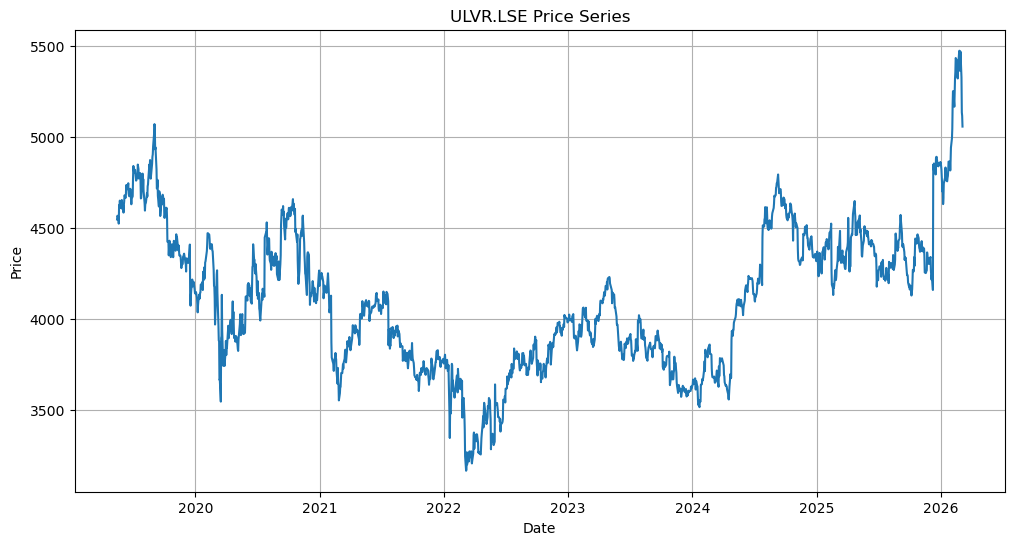

In [21]:
cache_candidates = [
    os.path.join('cache', f'{ticker}.csv'),
    os.path.join('..', 'cache', f'{ticker}.csv'),
]
cache_file = next((p for p in cache_candidates if os.path.exists(p)), None)

if ticker.upper().endswith('.LSE') and cache_file is not None:
    df_cached = pd.read_csv(cache_file, parse_dates=['Date']).set_index('Date').sort_index()
    s = df_cached['Close'].astype(float)
    s = f2.standardize_fx_daily_index(s)
    s = f2.trim_series(s, window_start, window_end)
    print(f'loaded cached EOD series from {cache_file} (using Close)')
else:
    s = f2.get_series(ticker, window_start, window_end)

start_trimmed = s.index[0].strftime('%Y-%m-%d')
end_trimmed = s.index[-1].strftime('%Y-%m-%d')
print(f'trimmed series for {ticker} with {len(s)} rows, from {start_trimmed} to {end_trimmed}')
plt.figure(figsize=(12, 6))
plt.plot(s.index, s.values)
plt.title(f'{ticker} Price Series')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid()
plt.show()

locate data source ATH for comparison to IBKR

In [10]:
sep_2019 = s.loc[(s.index >= "2019-09-01") & (s.index <= "2019-09-30")]

print(f"ticker={ticker}")
print(f"series date range: {s.index.min().date()} to {s.index.max().date()}")
print(f"series max in full selected window (Close): {s.max():.2f} on {s.idxmax().date()}")

if sep_2019.empty:
    print("No Sep-2019 points in series")
else:
    print(f"Sep-2019 max (Close): {sep_2019.max():.2f} on {sep_2019.idxmax().date()}")
    print(f"Sep-2019 min (Close): {sep_2019.min():.2f} on {sep_2019.idxmin().date()}")
    print("Last 10 Sep-2019 close rows:")
    display(sep_2019.tail(10))

# IBKR typically quotes high/low bars; compare High-to-High on same source window.
cache_candidates = [
    os.path.join('cache', f'{ticker}.csv'),
    os.path.join('..', 'cache', f'{ticker}.csv'),
]
cache_file = next((p for p in cache_candidates if os.path.exists(p)), None)
if cache_file is not None:
    df_cached = pd.read_csv(cache_file, parse_dates=['Date'])
    sep_df = df_cached[(df_cached['Date'] >= '2019-09-01') & (df_cached['Date'] <= '2019-09-30')]
    if 'High' in sep_df.columns and not sep_df.empty:
        idx = sep_df['High'].idxmax()
        print(f"Sep-2019 max (High): {sep_df.loc[idx, 'High']:.2f} on {sep_df.loc[idx, 'Date'].date()}")
        print(f"This is the field to compare against IBKR high prints.")

ticker=ULVR.LSE
series date range: 2019-05-16 to 2026-03-05
series max in full selected window (Close): 5472.00 on 2026-02-24
Sep-2019 max (Close): 5069.49 on 2019-09-03
Sep-2019 min (Close): 4565.78 on 2019-09-20
Last 10 Sep-2019 close rows:


Date
2019-09-17    4701.4707
2019-09-18    4693.3770
2019-09-19    4684.8072
2019-09-20    4565.7826
2019-09-23    4634.8169
2019-09-24    4670.0482
2019-09-25    4629.1037
2019-09-26    4668.6199
2019-09-27    4682.4267
2019-09-30    4656.2413
Name: Close, dtype: float64

Sep-2019 max (High): 5078.06 on 2019-09-04
This is the field to compare against IBKR high prints.


## Real-Data Sweeps
Run rolling-window sweeps on historical data and persist ranked outputs.

In [23]:
import importlib
import scripts.sample_window_sweep as sws

importlib.reload(sws)
from scripts.sample_window_sweep import (
    SweepConfig,
    sweep_sample_windows,
    save_sweep_results,
)

cfg = SweepConfig(
    position=position,
    trim_pct=trim_pct,
    take_profit_pct=take_profit_pct,
    min_months=min_months,
)
print(s.index[0],  s.index[-1])
sweep_df = sweep_sample_windows(s, ticker=ticker, config=cfg)

out_path = f"../cache/sweeps/{ticker.replace('.', '_')}_sample_window_sweep.parquet"
if sweep_df.empty:
    print("No sweep windows were produced.")
else:
    saved_path = save_sweep_results(sweep_df, out_path)
    print(f"Saved {len(sweep_df)} rows to: {saved_path}")
    display(
        sweep_df[[
            "window_months",
            "window_start",
            "window_end",
            "trim_count",
            "nav_profit_take",
            "nav_hold",
            "pnl_profit_take_vs_hold",
            "outperform_hold",
        ]].head(10)
    )

2019-05-16 00:00:00 2026-03-05 00:00:00
Saved 77 rows to: ../cache/sweeps/ULVR_LSE_sample_window_sweep.csv


,window_months,window_start,window_end,trim_count,nav_profit_take,nav_hold,pnl_profit_take_vs_hold,outperform_hold
0,6,2019-05-16,2019-11-18,1,44157.164400,43486.818,670.346400,True
1,7,2019-05-16,2019-12-16,1,44701.344900,44091.463,609.881900,True
2,8,2019-05-16,2020-01-16,1,42331.803300,41458.639,873.164300,True
3,9,2019-05-16,2020-02-17,2,44753.192010,44086.702,666.490010,True
4,10,2019-05-16,2020-03-16,2,37780.827840,35478.845,2301.982840,True
5,11,2019-05-16,2020-04-16,3,40875.971247,39325.719,1550.252247,True
6,12,2019-05-16,2020-05-18,3,41570.122860,40277.916,1292.206860,True
7,13,2019-05-16,2020-06-16,4,42814.041585,42068.045,745.996585,True
8,14,2019-05-16,2020-07-16,4,42145.574100,41049.195,1096.379100,True
9,15,2019-05-16,2020-08-17,5,43714.286762,43324.945,389.341762,True


Saved detail rows: 105336 to ../cache/sweeps/ULVR_LSE_param_grid_detail.csv
Saved ranked rows: 36 to ../cache/sweeps/ULVR_LSE_param_grid_ranked.csv


,take_profit_pct,trim_pct,windows,pct_outperform,avg_diff_nav,median_diff_nav,avg_trims,avg_return_profit_take,avg_return_hold
0,0.15,0.05,2926,44.087491,-52.792639,0.000000,3.317498,0.026678,0.028286
1,0.15,0.25,2926,43.916610,-167.831785,0.000000,3.317498,0.022708,0.028286
2,0.15,0.15,2926,43.779904,-120.629827,0.000000,3.317498,0.024409,0.028286
3,0.15,0.20,2926,43.779904,-145.063250,0.000000,3.317498,0.023528,0.028286
4,0.15,0.10,2926,43.711552,-91.264022,0.000000,3.317498,0.025426,0.028286
5,0.15,0.30,2926,43.506494,-191.422541,0.000000,3.317498,0.021890,0.028286
6,0.08,0.30,2926,43.233083,-932.416671,-878.183506,9.242310,0.000976,0.028286
7,0.05,0.30,2926,42.857143,-1050.037084,-1063.703254,17.550923,-0.003529,0.028286
8,0.08,0.25,2926,42.549556,-927.506739,-846.264719,9.242310,0.001568,0.028286
9,0.05,0.25,2926,42.378674,-1099.724960,-1081.198538,17.550923,-0.004205,0.028286


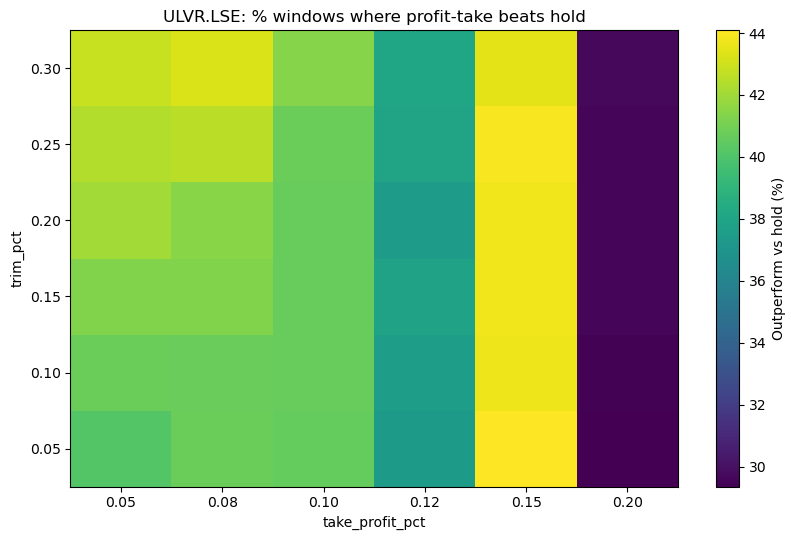

In [14]:
import importlib
import scripts.sample_window_sweep as sws

importlib.reload(sws)
from scripts.sample_window_sweep import run_grid_sweep

param_detail_df, param_ranked_df, detail_path, ranked_path = run_grid_sweep(
    prices=s,
    run_ticker=ticker,
    take_profit_vals=TP_VALS,
    trim_pct_vals=TRIM_VALS,
    min_months=min_months,
    roll_start_step_months=roll_start_step_months,
    position=position,
    save_outputs=True,
)

if param_ranked_df.empty:
    print("No parameter-grid results were produced.")
else:
    print(f"Saved detail rows: {len(param_detail_df)} to {detail_path}")
    print(f"Saved ranked rows: {len(param_ranked_df)} to {ranked_path}")

    display(param_ranked_df.head(12))

    # Best retained overview plot: parameter grid heatmap.
    heat = param_ranked_df.pivot(
        index="trim_pct",
        columns="take_profit_pct",
        values="pct_outperform",
    ).sort_index(ascending=True)

    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    im = ax.imshow(heat.values, aspect="auto", origin="lower", cmap="viridis")
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels([f"{x:.2f}" for x in heat.columns])
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels([f"{y:.2f}" for y in heat.index])
    ax.set_xlabel("take_profit_pct")
    ax.set_ylabel("trim_pct")
    ax.set_title(f"{ticker}: % windows where profit-take beats hold")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Outperform vs hold (%)")
    plt.tight_layout()
    plt.show()

In [15]:
if "param_detail_df" not in globals() or param_detail_df.empty:
    print("Run the parameter-grid cell first to create param_detail_df.")
else:
    d = param_detail_df.copy()
    d["window_start"] = pd.to_datetime(d["window_start"])
    d["window_end"] = pd.to_datetime(d["window_end"])

    # 1) Best single period+parameter outcome
    best_single = d.sort_values("pnl_profit_take_vs_hold", ascending=False).head(10)
    print("Top 10 single outcomes (period + params) by NAV difference vs hold:")
    display(
        best_single[[
            "window_start",
            "window_end",
            "window_months",
            "take_profit_pct",
            "trim_pct",
            "pnl_profit_take_vs_hold",
            "outperform_hold",
        ]]
    )

    # 2) Most robust periods across parameter sets
    period_robust = (
        d.groupby(["window_start", "window_end", "window_months"], as_index=False)
         .agg(
             param_tests=("run_id", "count"),
             pct_params_outperform=("outperform_hold", "mean"),
             avg_diff_nav=("pnl_profit_take_vs_hold", "mean"),
             median_diff_nav=("pnl_profit_take_vs_hold", "median"),
             best_diff_nav=("pnl_profit_take_vs_hold", "max"),
             worst_diff_nav=("pnl_profit_take_vs_hold", "min"),
         )
         .sort_values(["pct_params_outperform", "avg_diff_nav"], ascending=[False, False])
         .reset_index(drop=True)
    )
    period_robust["pct_params_outperform"] = period_robust["pct_params_outperform"] * 100.0

    print("Top 15 robust periods (ranked by % of parameter sets beating hold, then avg NAV diff):")
    display(period_robust.head(15))

    # Save period ranking for later review
    period_rank_path = save_sweep_results(
        period_robust,
        f"../cache/sweeps/{ticker.replace('.', '_')}_period_robustness_ranked.parquet",
    )
    print(f"Saved period robustness ranking to: {period_rank_path}")

Top 10 single outcomes (period + params) by NAV difference vs hold:


,window_start,window_end,window_months,take_profit_pct,trim_pct,pnl_profit_take_vs_hold,outperform_hold
16378,2019-05-16,2022-03-16,34,0.05,0.30,13863.658504,True
16416,2019-05-16,2022-04-19,35,0.05,0.30,13768.597914,True
13452,2019-05-16,2022-03-16,34,0.05,0.25,13321.413657,True
13490,2019-05-16,2022-04-19,35,0.05,0.25,13226.825237,True
16337,2019-07-17,2022-04-19,33,0.05,0.30,13162.522020,True
16406,2019-06-17,2022-04-19,34,0.05,0.30,13162.522020,True
16294,2019-07-17,2022-03-17,32,0.05,0.30,12991.048637,True
16330,2019-06-17,2022-03-17,33,0.05,0.30,12991.048637,True
10526,2019-05-16,2022-03-16,34,0.05,0.20,12638.166706,True
13480,2019-06-17,2022-04-19,34,0.05,0.25,12574.841982,True


Top 15 robust periods (ranked by % of parameter sets beating hold, then avg NAV diff):


,window_start,window_end,window_months,param_tests,pct_params_outperform,avg_diff_nav,median_diff_nav,best_diff_nav,worst_diff_nav
0,2019-05-16,2022-03-16,34,36,100.0,7193.990527,7207.835726,13863.658504,519.18515
1,2019-05-16,2022-04-19,35,36,100.0,7135.297482,7142.621035,13768.597914,514.42420
2,2019-06-17,2022-04-19,34,36,100.0,6737.644489,6758.487775,13162.522020,514.42420
3,2019-07-17,2022-04-19,33,36,100.0,6737.644489,6758.487775,13162.522020,514.42420
4,2019-06-17,2022-03-17,33,36,100.0,6631.095742,6627.817618,12991.048637,505.85440
5,2019-07-17,2022-03-17,32,36,100.0,6631.095742,6627.817618,12991.048637,505.85440
6,2019-05-16,2022-06-16,37,36,100.0,6390.702956,6326.206283,12512.231931,451.57920
7,2019-08-19,2022-03-21,31,36,100.0,6098.369773,6261.874818,12142.618442,522.04175
8,2019-08-19,2022-04-19,32,36,100.0,6007.420947,6177.292247,11990.636314,514.42420
9,2019-12-23,2022-03-23,27,36,100.0,5964.792047,6374.141256,9928.763696,531.80175


Saved period robustness ranking to: ../cache/sweeps/ULVR_LSE_period_robustness_ranked.csv


In [16]:
if "param_detail_df" not in globals() or param_detail_df.empty:
    print("Run the parameter-grid cell first.")
else:
    d = param_detail_df.copy()
    d["window_start"] = pd.to_datetime(d["window_start"])
    d["window_end"] = pd.to_datetime(d["window_end"])

    def ols_slope_logprice(series: pd.Series) -> float:
        y = np.log(series.astype(float).values)
        if len(y) < 3:
            return np.nan
        x = np.arange(len(y), dtype=float)
        x = x - x.mean()
        y = y - y.mean()
        denom = np.dot(x, x)
        if denom == 0:
            return np.nan
        return float(np.dot(x, y) / denom)

    # Compute one slope per unique period
    period_slopes = (
        d[["window_start", "window_end"]]
        .drop_duplicates()
        .assign(
            ols_slope=lambda z: z.apply(
                lambda r: ols_slope_logprice(
                    s.loc[(s.index >= r["window_start"]) & (s.index <= r["window_end"])]
                ),
                axis=1,
            )
        )
    )
    period_slopes["slope_regime"] = np.where(period_slopes["ols_slope"] < 0, "down", "up_or_flat")

    merged = d.merge(period_slopes, on=["window_start", "window_end"], how="left")

    regime_stats = (
        merged.groupby("slope_regime", as_index=False)
        .agg(
            rows=("run_id", "count"),
            pct_outperform=("outperform_hold", "mean"),
            avg_diff_nav=("pnl_profit_take_vs_hold", "mean"),
            median_diff_nav=("pnl_profit_take_vs_hold", "median"),
        )
        .sort_values("slope_regime")
    )
    regime_stats["pct_outperform"] = regime_stats["pct_outperform"] * 100.0

    print("Profit-take vs hold by OLS slope regime (window-level):")
    display(regime_stats)

    # Correlation check: slope vs relative performance
    period_level = (
        merged.groupby(["window_start", "window_end", "ols_slope", "slope_regime"], as_index=False)
        .agg(avg_diff_nav=("pnl_profit_take_vs_hold", "mean"))
    )
    corr = period_level[["ols_slope", "avg_diff_nav"]].corr().iloc[0, 1]
    print(f"Correlation(OLS slope, avg_diff_nav) = {corr:.3f}")

Profit-take vs hold by OLS slope regime (window-level):


,slope_regime,rows,pct_outperform,avg_diff_nav,median_diff_nav
0,down,49248,65.218892,1060.431576,560.897336
1,up_or_flat,56088,16.329696,-2131.521852,-1215.450400


Correlation(OLS slope, avg_diff_nav) = -0.413


In [17]:
if "param_detail_df" not in globals() or param_detail_df.empty:
    print("Run the parameter-grid cell first.")
else:
    overall_rate = 100.0 * param_detail_df["outperform_hold"].mean()
    best_row = param_ranked_df.sort_values("pct_outperform", ascending=False).iloc[0]
    med_rate = param_ranked_df["pct_outperform"].median()
    p75_rate = param_ranked_df["pct_outperform"].quantile(0.75)

    print(f"Overall trim outperformance rate (all windows x all params): {overall_rate:.2f}%")
    print(f"Median outperformance rate across parameter combos: {med_rate:.2f}%")
    print(f"75th percentile combo outperformance rate: {p75_rate:.2f}%")
    print("Best combo by outperformance rate:")
    display(best_row.to_frame().T[[
        "take_profit_pct",
        "trim_pct",
        "windows",
        "pct_outperform",
        "avg_diff_nav",
        "median_diff_nav",
        "avg_trims",
    ]])

Overall trim outperformance rate (all windows x all params): 39.19%
Median outperformance rate across parameter combos: 40.74%
75th percentile combo outperformance rate: 42.42%
Best combo by outperformance rate:


,take_profit_pct,trim_pct,windows,pct_outperform,avg_diff_nav,median_diff_nav,avg_trims
0,0.15,0.05,2926.0,44.087491,-52.792639,0.0,3.317498


## Regime Drift
Inspect how trim-vs-hold edge evolves over time by window end date.

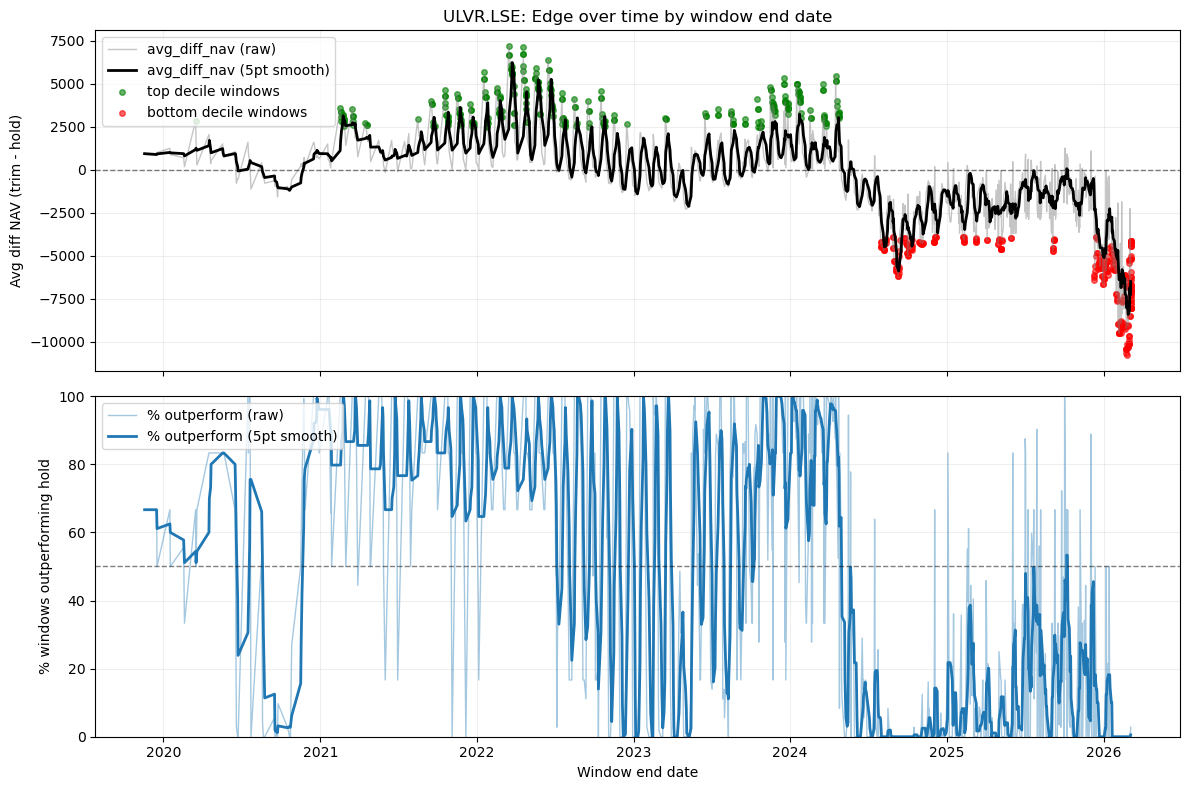

Tail of end-date view:


,window_end,avg_diff_nav,pct_outperform,n_windows,avg_diff_nav_smooth,pct_out_smooth
939,2026-02-20,-6294.872811,0.000000,3,-7210.500292,0.000000
940,2026-02-23,-9238.603228,0.000000,6,-7379.816392,0.000000
941,2026-02-24,-8973.959511,0.000000,5,-8047.890731,0.000000
942,2026-02-25,-6309.586737,0.000000,2,-7689.274416,0.000000
943,2026-02-26,-9074.627539,0.000000,2,-7978.329966,0.000000
944,2026-02-27,-8504.986654,0.000000,4,-8420.352734,0.000000
945,2026-03-02,-8121.178845,0.000000,11,-8196.867857,0.000000
946,2026-03-03,-2270.772136,0.000000,2,-6856.230382,0.000000
947,2026-03-04,-8493.238647,0.000000,2,-7292.960764,0.000000
948,2026-03-05,-5154.066142,2.777778,65,-6508.848485,0.555556


In [18]:
if "param_detail_df" not in globals() or param_detail_df.empty:
    print("Run the parameter-grid cell first.")
else:
    d = param_detail_df.copy()
    d["window_start"] = pd.to_datetime(d["window_start"])
    d["window_end"] = pd.to_datetime(d["window_end"])

    # One score per window (across all parameter combinations)
    win = (
        d.groupby(["window_start", "window_end"], as_index=False)
         .agg(
             avg_diff_nav=("pnl_profit_take_vs_hold", "mean"),
             pct_outperform=("outperform_hold", "mean"),
             tests=("run_id", "count"),
         )
    )
    win["pct_outperform"] = 100.0 * win["pct_outperform"]

    # Top/bottom deciles by window quality
    q10 = win["avg_diff_nav"].quantile(0.10)
    q90 = win["avg_diff_nav"].quantile(0.90)
    top = win[win["avg_diff_nav"] >= q90].copy()
    bot = win[win["avg_diff_nav"] <= q10].copy()

    # Aggregate by window_end to show edge drift over time
    end_view = (
        win.groupby("window_end", as_index=False)
           .agg(
               avg_diff_nav=("avg_diff_nav", "mean"),
               pct_outperform=("pct_outperform", "mean"),
               n_windows=("window_start", "count"),
           )
           .sort_values("window_end")
    )

    # Light smoothing to reduce daily noise from overlapping windows
    end_view["avg_diff_nav_smooth"] = end_view["avg_diff_nav"].rolling(5, min_periods=1).mean()
    end_view["pct_out_smooth"] = end_view["pct_outperform"].rolling(5, min_periods=1).mean()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    ax1.plot(end_view["window_end"], end_view["avg_diff_nav"], color="gray", alpha=0.45, lw=1.0, label="avg_diff_nav (raw)")
    ax1.plot(end_view["window_end"], end_view["avg_diff_nav_smooth"], color="black", lw=2.0, label="avg_diff_nav (5pt smooth)")
    ax1.scatter(top["window_end"], top["avg_diff_nav"], color="green", s=16, alpha=0.6, label="top decile windows")
    ax1.scatter(bot["window_end"], bot["avg_diff_nav"], color="red", s=16, alpha=0.6, label="bottom decile windows")
    ax1.axhline(0.0, color="black", lw=1, ls="--", alpha=0.5)
    ax1.set_ylabel("Avg diff NAV (trim - hold)")
    ax1.set_title(f"{ticker}: Edge over time by window end date")
    ax1.grid(alpha=0.2)
    ax1.legend(loc="upper left")

    ax2.plot(end_view["window_end"], end_view["pct_outperform"], color="tab:blue", alpha=0.4, lw=1.0, label="% outperform (raw)")
    ax2.plot(end_view["window_end"], end_view["pct_out_smooth"], color="tab:blue", lw=2.0, label="% outperform (5pt smooth)")
    ax2.axhline(50.0, color="black", lw=1, ls="--", alpha=0.5)
    ax2.set_ylabel("% windows outperforming hold")
    ax2.set_xlabel("Window end date")
    ax2.set_ylim(0, 100)
    ax2.grid(alpha=0.2)
    ax2.legend(loc="upper left")

    plt.tight_layout()
    plt.show()

    print("Tail of end-date view:")
    display(end_view.tail(10))

## Tail Objective and Pareto Frontier
Rank parameter sets for left-tail protection while retaining right-tail participation.

Top 12 parameter combos for LEFT-TAIL protection with RIGHT-TAIL retention:


,take_profit_pct,trim_pct,windows,left_tail_p05,left_tail_p10,right_tail_p90,right_tail_p95,mean_diff,median_diff,pct_outperform,tail_objective_score
0,0.15,0.05,2926,-1301.414891,-811.192511,832.853059,1140.419240,-52.792639,0.000000,44.087491,0.695027
1,0.15,0.10,2926,-2345.276326,-1528.268520,1572.680675,2084.601090,-91.264022,0.000000,43.711552,0.659714
2,0.15,0.15,2926,-3234.459928,-2164.554562,2224.228148,2925.125104,-120.629827,0.000000,43.779904,0.633873
3,0.15,0.20,2926,-4064.081534,-2700.898022,2758.996418,3595.731883,-145.063250,0.000000,43.779904,0.604312
4,0.20,0.05,2926,-740.244198,-480.311810,235.989994,346.614412,-107.961966,-17.139550,29.357485,0.600000
5,0.15,0.25,2926,-4799.598182,-3200.082792,3219.233714,4144.323816,-167.831785,0.000000,43.916610,0.577004
6,0.10,0.05,2926,-2945.568386,-2172.573589,1026.575308,1645.182574,-406.541202,-127.079600,40.601504,0.576380
7,0.12,0.05,2926,-2259.597508,-1676.912518,639.426795,1001.764105,-371.019070,-122.603121,37.388927,0.575085
8,0.20,0.10,2926,-1420.877237,-926.296860,471.956140,687.247800,-207.430027,-34.279100,29.425837,0.566959
9,0.15,0.30,2926,-5329.677112,-3613.049646,3564.474350,4604.995015,-191.422541,0.000000,43.506494,0.556754


Pareto candidates (cannot improve left tail without giving up right tail, and vice versa):


,take_profit_pct,trim_pct,left_tail_p05,right_tail_p95
30,0.20,0.05,-740.244198,346.614412
24,0.15,0.05,-1301.414891,1140.419240
25,0.15,0.10,-2345.276326,2084.601090
26,0.15,0.15,-3234.459928,2925.125104
27,0.15,0.20,-4064.081534,3595.731883
28,0.15,0.25,-4799.598182,4144.323816
29,0.15,0.30,-5329.677112,4604.995015
15,0.10,0.20,-7031.818178,4734.037942
16,0.10,0.25,-7433.326401,5392.592187
17,0.10,0.30,-7783.830774,5962.545606


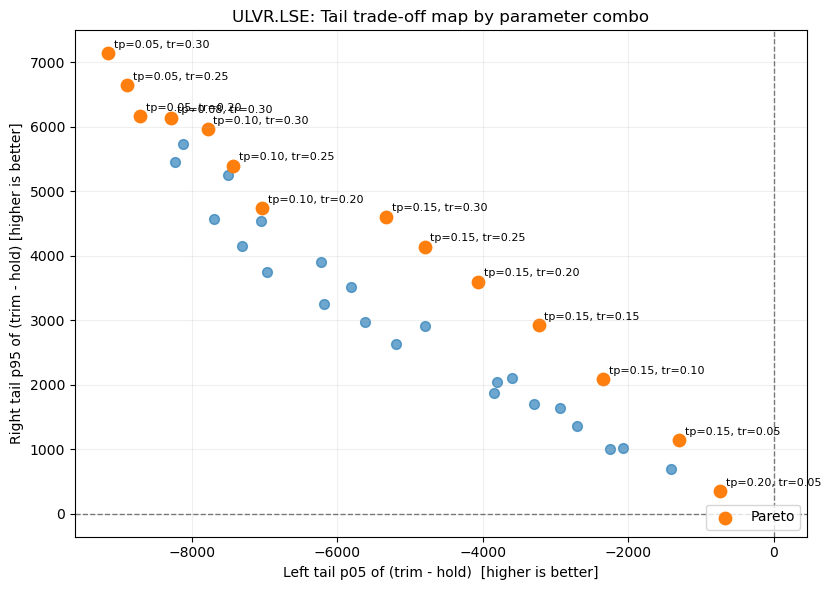

Saved tail-objective ranking to: ../cache/sweeps/ULVR_LSE_param_grid_tail_objective_ranked.csv


In [19]:
if "param_detail_df" not in globals() or param_detail_df.empty:
    print("Run the parameter-grid cell first.")
else:
    d = param_detail_df.copy()

    # Relative edge vs hold per window; positive means trimming beats hold.
    rel = d["pnl_profit_take_vs_hold"].astype(float)

    # Tail-aware diagnostics per parameter set.
    tail = (
        d.assign(rel_diff=rel)
         .groupby(["take_profit_pct", "trim_pct"], as_index=False)
         .agg(
             windows=("run_id", "count"),
             mean_diff=("rel_diff", "mean"),
             median_diff=("rel_diff", "median"),
             left_tail_p05=("rel_diff", lambda x: x.quantile(0.05)),
             left_tail_p10=("rel_diff", lambda x: x.quantile(0.10)),
             right_tail_p90=("rel_diff", lambda x: x.quantile(0.90)),
             right_tail_p95=("rel_diff", lambda x: x.quantile(0.95)),
             pct_outperform=("outperform_hold", "mean"),
         )
    )
    tail["pct_outperform"] = 100.0 * tail["pct_outperform"]

    # Normalize for a composite objective:
    # 1) maximize left-tail protection (higher p05 is better, less negative)
    # 2) minimize right-tail give-up (higher p95 is better)
    # 3) keep broad robustness (% windows outperform)
    def _minmax(s: pd.Series) -> pd.Series:
        lo, hi = s.min(), s.max()
        if pd.isna(lo) or pd.isna(hi) or hi == lo:
            return pd.Series(np.ones(len(s)), index=s.index)
        return (s - lo) / (hi - lo)

    tail["score_left"] = _minmax(tail["left_tail_p05"])
    tail["score_right"] = _minmax(tail["right_tail_p95"])
    tail["score_robust"] = _minmax(tail["pct_outperform"])

    # Heavier weight on left tail per your objective.
    w_left, w_right, w_robust = 0.60, 0.30, 0.10
    tail["tail_objective_score"] = (
        w_left * tail["score_left"]
        + w_right * tail["score_right"]
        + w_robust * tail["score_robust"]
    )

    ranked_tail = tail.sort_values("tail_objective_score", ascending=False).reset_index(drop=True)

    print("Top 12 parameter combos for LEFT-TAIL protection with RIGHT-TAIL retention:")
    display(
        ranked_tail[[
            "take_profit_pct",
            "trim_pct",
            "windows",
            "left_tail_p05",
            "left_tail_p10",
            "right_tail_p90",
            "right_tail_p95",
            "mean_diff",
            "median_diff",
            "pct_outperform",
            "tail_objective_score",
        ]].head(12)
    )

    # Pareto-style filter: non-dominated on (left_tail_p05, right_tail_p95)
    p = tail[["take_profit_pct", "trim_pct", "left_tail_p05", "right_tail_p95"]].copy()
    is_dominated = []
    for i, r in p.iterrows():
        dom = (
            (p["left_tail_p05"] >= r["left_tail_p05"]) &
            (p["right_tail_p95"] >= r["right_tail_p95"]) &
            ((p["left_tail_p05"] > r["left_tail_p05"]) | (p["right_tail_p95"] > r["right_tail_p95"]))
        ).any()
        is_dominated.append(dom)
    pareto = p.loc[~pd.Series(is_dominated, index=p.index)].sort_values(["left_tail_p05", "right_tail_p95"], ascending=False)

    print("Pareto candidates (cannot improve left tail without giving up right tail, and vice versa):")
    display(pareto)

    # Visualize trade-off frontier.
    fig, ax = plt.subplots(figsize=(8.5, 6))
    ax.scatter(tail["left_tail_p05"], tail["right_tail_p95"], alpha=0.65, s=50, color="tab:blue")
    ax.scatter(pareto["left_tail_p05"], pareto["right_tail_p95"], s=80, color="tab:orange", label="Pareto")

    for _, r in pareto.iterrows():
        ax.annotate(
            f"tp={r['take_profit_pct']:.2f}, tr={r['trim_pct']:.2f}",
            (r["left_tail_p05"], r["right_tail_p95"]),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=8,
        )

    ax.axvline(0.0, color="black", lw=1, ls="--", alpha=0.5)
    ax.axhline(0.0, color="black", lw=1, ls="--", alpha=0.5)
    ax.set_xlabel("Left tail p05 of (trim - hold)  [higher is better]")
    ax.set_ylabel("Right tail p95 of (trim - hold) [higher is better]")
    ax.set_title(f"{ticker}: Tail trade-off map by parameter combo")
    ax.grid(alpha=0.2)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    # Optional: save tail-focused ranking.
    tail_rank_path = save_sweep_results(
        ranked_tail,
        f"../cache/sweeps/{ticker.replace('.', '_')}_param_grid_tail_objective_ranked.parquet",
    )
    print(f"Saved tail-objective ranking to: {tail_rank_path}")

## Synthetic Stress Scenarios
Apply the same tail-objective ranking to synthetic regimes (fat tails, jumps, crash/recovery, oscillation).

In [24]:
import importlib
import scripts.synthetic_generators as sg
import scripts.sample_window_sweep as sws

importlib.reload(sg)
importlib.reload(sws)
from scripts.sample_window_sweep import run_grid_sweep, save_sweep_results

suite = sg.build_synthetic_suite(n_days=252 * 8, price0=100.0, start="2018-01-01")

scenario_tables = []
scenario_best = []

for scenario, syn_series in suite.items():
    detail_df, _, _, _ = run_grid_sweep(
        prices=syn_series,
        run_ticker=f"SYN_{scenario}",
        take_profit_vals=TP_VALS,
        trim_pct_vals=TRIM_VALS,
        min_months=min_months,
        roll_start_step_months=roll_start_step_months,
        position=position,
        save_outputs=False,
    )

    if detail_df.empty:
        continue

    d = detail_df.copy()
    d["scenario"] = scenario
    d["rel_diff"] = d["pnl_profit_take_vs_hold"].astype(float)

    t = (
        d.groupby(["scenario", "take_profit_pct", "trim_pct"], as_index=False)
        .agg(
            windows=("run_id", "count"),
            left_p05=("rel_diff", lambda x: x.quantile(0.05)),
            left_p10=("rel_diff", lambda x: x.quantile(0.10)),
            cvar05=("rel_diff", lambda x: x[x <= x.quantile(0.05)].mean() if len(x) else np.nan),
            right_p90=("rel_diff", lambda x: x.quantile(0.90)),
            right_p95=("rel_diff", lambda x: x.quantile(0.95)),
            pct_outperform=("outperform_hold", "mean"),
            mean_diff=("rel_diff", "mean"),
            median_diff=("rel_diff", "median"),
        )
    )
    t["pct_outperform"] = 100.0 * t["pct_outperform"]

    def _mm(col: pd.Series) -> pd.Series:
        lo, hi = col.min(), col.max()
        if pd.isna(lo) or pd.isna(hi) or hi == lo:
            return pd.Series(np.ones(len(col)), index=col.index)
        return (col - lo) / (hi - lo)

    t["score_left"] = _mm(t["left_p05"])
    t["score_right"] = _mm(t["right_p95"])
    t["score_robust"] = _mm(t["pct_outperform"])
    t["tail_score"] = 0.60 * t["score_left"] + 0.30 * t["score_right"] + 0.10 * t["score_robust"]

    scenario_tables.append(t)
    scenario_best.append(t.sort_values("tail_score", ascending=False).head(1))

if not scenario_tables:
    print("No synthetic scenario outputs were produced.")
else:
    synthetic_tail_df = pd.concat(scenario_tables, ignore_index=True)
    synthetic_tail_best_df = pd.concat(scenario_best, ignore_index=True).sort_values("scenario").reset_index(drop=True)

    print("Best parameter combo per synthetic scenario (tail objective):")
    display(
        synthetic_tail_best_df[[
            "scenario",
            "take_profit_pct",
            "trim_pct",
            "windows",
            "left_p05",
            "left_p10",
            "cvar05",
            "right_p90",
            "right_p95",
            "pct_outperform",
            "tail_score",
        ]]
    )

    synthetic_out = save_sweep_results(
        synthetic_tail_df.sort_values(["scenario", "tail_score"], ascending=[True, False]),
        "../cache/sweeps/synthetic_tail_objective_ranked.parquet",
    )
    print(f"Saved synthetic tail ranking to: {synthetic_out}")

Best parameter combo per synthetic scenario (tail objective):


,scenario,take_profit_pct,trim_pct,windows,left_p05,left_p10,cvar05,right_p90,right_p95,pct_outperform,tail_score
0,crash_recovery,0.20,0.05,3768,-71.191902,-43.468178,-90.543788,80.957279,92.010117,57.139066,0.628270
1,flat_oscillation,0.15,0.15,3768,-5.636058,16.323013,-22.150845,263.975830,300.773141,93.497877,0.940345
2,jump_down,0.05,0.30,3768,2.037755,9.568394,-34.186869,510.896846,540.545355,96.337580,1.000000
3,student_t,0.20,0.30,3768,0.000000,0.000000,-2.575865,230.600969,247.651508,69.161359,0.720821


Saved synthetic tail ranking to: ../cache/sweeps/synthetic_tail_objective_ranked.csv


## Optional Single-Path Sanity Check
One-off single-path run for debugging and intuition. Keep conclusions based on the sweep sections above.

In [ ]:


position = 1000
trim_pct = 0.10
take_profit_pct = 0.10

entry_price = s.iloc[0]
initial_position = position
initial_value = (entry_price * position) / 100

print('entry date', s.index[0].date(), 'at price', f"{entry_price:.2f}")
print('exit date', s.index[-1].date(), 'at price', f"{s.iloc[-1]:.2f}")
print('duration in months:', round((s.index[-1] - s.index[0]).days / 30, 1), 'months')
print(f"Position: {position} shares")
print(f"Initial position value: {initial_value:.0f}")


#  Loop through series and apply take-profit logic
total_cash = 0.0  # gross sale proceeds
tot_realized_pnl = 0.0
pnl_snapshots = []
trim_dates = []
trim_date = None

last_price = entry_price
low = entry_price
print('----LOOP-----')
for date, price in s.items():
    # if price < low:
        # print('-----new low', price)
    low = min(price, low)
    if (price / low - 1) > take_profit_pct:
        # print('=' * 20)
        # print(f"/////// Take profit on {date.date()} at price {price:.2f}")
        trim_date = date
        # last_price = price
        # print('trim_date set to:', trim_date.date())

        low = price  # reset low after take-profit trigger
        # print('+++++low reset to:', low)

        # PnL before trim on full current position
        pnl_before = ((price - entry_price) * position) / 100
        # print(f"Value before trim: {(price * position) / 100:.0f}")
        # print(f"PnL before trim ({position:.0f} sh): {pnl_before:.0f}")
        # print('.......')

        # Trim a fraction of current shares
        shares_to_trim = position * trim_pct
        this_pnl = ((price - entry_price) * shares_to_trim) / 100
        tot_realized_pnl += this_pnl
        cash = (price * shares_to_trim) / 100
        total_cash += cash
        position -= shares_to_trim

        unrealized_pnl = ((price - entry_price) * position) / 100
        total_pnl = tot_realized_pnl + unrealized_pnl

        trim_dates.append((trim_date, price, this_pnl))

        # print(f"Trimmed shares: {shares_to_trim:.0f} leaves {position:.0f}")
        # print(f"Cash (sale proceeds): {cash:.0f}")
        # print(f"PnL from trimmed shares: {this_pnl:.0f}")
        # print(f"Total Realized PnL: {tot_realized_pnl:.0f}")
        # print(f"Unrealized PnL: {unrealized_pnl:.0f}")
        # print(f"Total PnL after trim: {total_pnl:.0f}")
        # print('value after trim:', round((price * position) / 100))

        # break
# print('=======END=======')
if trim_date is None:
    print('No take-profit trigger hit in sample window.')
# for d in trim_dates:
    # print('Trim date:', d[0].date(), 'at price', f"{d[1]:.2f}")
print('total_cash from trims:', round(total_cash))
nav_after_trims = total_cash + (s.iloc[-1] * position) / 100
nav_without_trims = (s.iloc[-1] * initial_position) / 100
trim_pnl = nav_after_trims - nav_without_trims
print('final NAV after trimming: ', round(nav_after_trims))
print('final NAV without trimming: ', round(nav_without_trims))
print('PnL from trims:', round(trim_pnl))


## Porting Checklist

- [ ] Create a fresh branch in the target repo for this port.
- [ ] Copy updated files:
  - [ ] `various/backtest.ipynb`
  - [ ] `scripts/sample_window_sweep.py`
  - [ ] `fx_hedges/fxshort_gates.py`
- [ ] Decide archive strategy:
  - [ ] Include `archive/_legacy/` in port
  - [ ] Or exclude `archive/_legacy/` and keep only in staging copy
- [ ] Verify imports resolve in target repo:
  - [ ] `scripts.sample_window_sweep`
  - [ ] `scripts.synthetic_generators`
  - [ ] `functions1`, `functions2`, `config`
- [ ] Verify path assumptions:
  - [ ] `cache/...`
  - [ ] `../cache/sweeps/...`
- [ ] Run notebook through Real-Data Sweeps section:
  - [ ] Grid detail/ranked files save
  - [ ] Heatmap renders
- [ ] Run notebook through Synthetic Stress Scenarios section:
  - [ ] Scenario summary table renders
  - [ ] `synthetic_tail_objective_ranked` output saves
- [ ] Spot-check output parity vs staging copy:
  - [ ] Top ranked parameter rows align
  - [ ] Key `% outperform` values align
- [ ] Scan for duplicate/legacy clutter in target repo:
  - [ ] `*copy*`
  - [ ] `*bkp*`
  - [ ] `*copi*`
  - [ ] `Z_OLD`-style leftovers
- [ ] Commit in two logical chunks:
  - [ ] `scripts/*.py` + `fx_hedges/*.py`
  - [ ] `various/backtest.ipynb`
- [ ] Use commit/PR notes that state:
  - [ ] Shared `run_grid_sweep` path for real + synthetic sweeps
  - [ ] Notebook cleanup (wording/structure)
  - [ ] Archive handling decision
- [ ] Open PR with validation summary:
  - [ ] Real sweep run OK
  - [ ] Synthetic sweep run OK
  - [ ] Outputs generated
  - [ ] No logic drift observed

1. Add `cooldown_days` after each trim to reduce clustered trims and over-trading in chop.
2. Add `rearm_drop_pct` so a new trim is only allowed after a meaningful pullback from post-trim high.
3. Add volatility-based trimming as a controlled upgrade:
`effective_trim_pct = base_trim_pct * clip(vol / vol_target, min_mult, max_mult)`.
4. Keep vol model simple at first:
fixed lookback (e.g., 20d), fixed target vol, bounded multipliers.
5. Add “buy on X dip” only with strict controls:
use trim-generated cash only, cap max position, keep cash buffer.
6. For dip-buy logic, track attribution separately:
trim PnL vs dip-buy PnL vs combined PnL.
7. Use regime identification as a state filter, not prediction:
`risk_on/risk_off` gating of existing trim aggressiveness.
8. Build regime filters from observable, real-time features:
trend (MA), vol percentile, drawdown depth.
9. Add hysteresis/persistence to regime rules to prevent flip-flopping.
10. Validate regime logic walk-forward/out-of-sample, not full-sample tuned.
11. Quantify slope quality (not just slope direction):
use `R^2`, slope t-stat, slope-to-noise, and sign stability across subwindows.
12. Use slope quality to modulate trims:
high-quality uptrend -> lighter trims; weak/noisy trend -> heavier trims.
13. Keep all additions incremental:
one new mechanism at a time, compare against your current baseline on identical windows.
14. Include practical realism overlays in evaluation:
costs/slippage/taxes/execution assumptions.
15. For process safety in real repo:
work on a feature branch, small commits, PR review, and branch protections on `main`.